# load full dataset kDist

## bert-base layer 12

In [1]:
# load the data
import pandas as pd

#k_50_df = pd.read_csv("../data/sorted_k_dist/k_distance_50.csv")
k_100_df = pd.read_csv("../../data/sorted_k_dist/k_distance_100.csv")
k_500_df = pd.read_csv("../../data/sorted_k_dist/k_distance_500.csv")
k_1000_df = pd.read_csv("../../data/sorted_k_dist/k_distance_1000.csv")

#k_50_df = k_50_df.rename(columns={"rank": "rank_50", "k_distance": "k_distance_50"})
k_100_df = k_100_df.rename(columns={"rank": "rank_100", "k_distance": "k_distance_100"})
k_500_df = k_500_df.rename(columns={"rank": "rank_500", "k_distance": "k_distance_500"})
k_1000_df = k_1000_df.rename(columns={"rank": "rank_1000", "k_distance": "k_distance_1000"})

k_dists_full = (
k_100_df
    #.merge(k_100_df, on="id", how="inner")
    .merge(k_500_df, on="id", how="inner")
    .merge(k_1000_df, on="id", how="inner")
)

k_dists_full.head()

,rank_100,id,k_distance_100,rank_500,k_distance_500,rank_1000,k_distance_1000
0,0,309742,0.034094,383,0.064553,670,0.079248
1,1,434369,0.035180,40,0.057281,212,0.073101
2,2,515689,0.035239,45,0.057602,188,0.072600
3,3,15563,0.035341,178,0.061263,310,0.074616
4,4,461368,0.035475,46,0.057614,157,0.071840


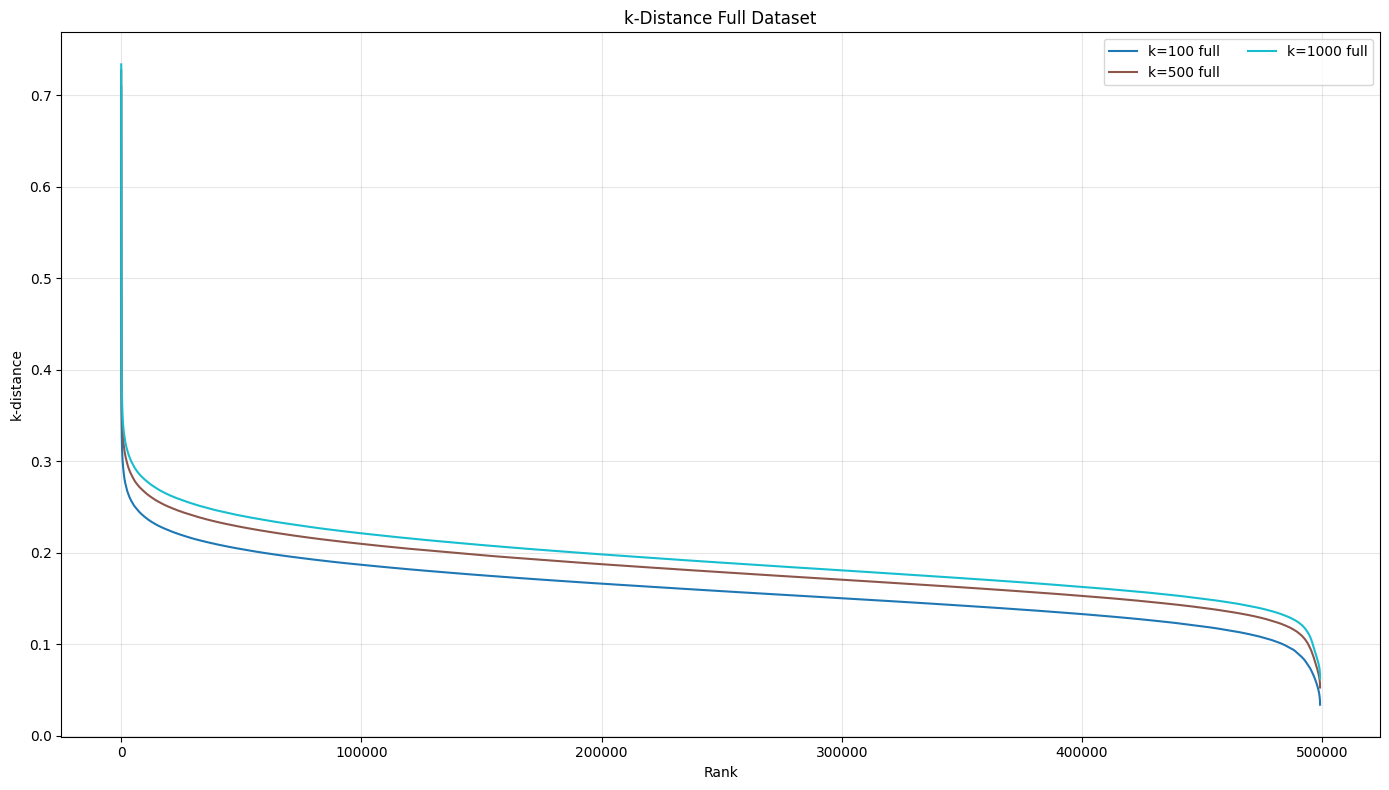

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb

k_values = [100, 500, 1000]

fig, ax = plt.subplots(figsize=(14, 8))

colors = plt.cm.tab10(np.linspace(0, 1, len(k_values)))

for k, color in zip(k_values, colors):

    # Full dataset
    full_distances = k_dists_full[f"k_distance_{k}"].values
    full_distances_sorted = np.sort(full_distances)[::-1]
    full_rank = np.arange(len(full_distances_sorted))

    # Create lighter version of the color
    rgb = np.array(to_rgb(color))
    light_color = rgb + (1 - rgb) * 0.6

    # Full dataset
    ax.plot(
        full_rank,
        full_distances_sorted,
        color=color,
        label=f"k={k} full"
    )


ax.set_xlabel("Rank")
ax.set_ylabel("k-distance")
ax.set_title("k-Distance Full Dataset")
ax.legend(ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# load sample kDist

## bert-base layer 12

In [3]:
#k_5_sample = pd.read_csv("../data/sorted_k_dist/results_kdist_bertbase_sample/k_distance_bb_last_5.csv")
k_10_sample = pd.read_csv("../../data/sorted_k_dist/results_kdist_bertbase_sample/k_distance_bb_last_10.csv")
k_50_sample = pd.read_csv("../../data/sorted_k_dist/results_kdist_bertbase_sample/k_distance_bb_last_50.csv")
k_100_sample = pd.read_csv("../../data/sorted_k_dist/results_kdist_bertbase_sample/k_distance_bb_last_100.csv")

#k_5_sample = k_5_sample.rename(columns={"rank": "rank_5", "k_distance": "k_distance_5"})
k_10_sample = k_10_sample.rename(columns={"rank": "rank_10", "k_distance": "k_distance_10"})
k_50_sample = k_50_sample.rename(columns={"rank": "rank_50", "k_distance": "k_distance_50"})
k_100_sample = k_100_sample.rename(columns={"rank": "rank_100", "k_distance": "k_distance_100"})

k_dists_sample = (
    k_10_sample
    #.merge(k_10_sample, on="id", how="inner")
    .merge(k_50_sample, on="id", how="inner")
    .merge(k_100_sample, on="id", how="inner")
)

k_dists_sample.head()

,rank_10,id,k_distance_10,rank_50,k_distance_50,rank_100,k_distance_100
0,0,537643,0.035480,0,0.054783,0,0.064506
1,1,537628,0.035666,1,0.054784,1,0.064860
2,2,537608,0.036153,2,0.057103,2,0.067066
3,3,537594,0.036154,3,0.057245,3,0.068661
4,4,537593,0.037261,4,0.059481,4,0.069068


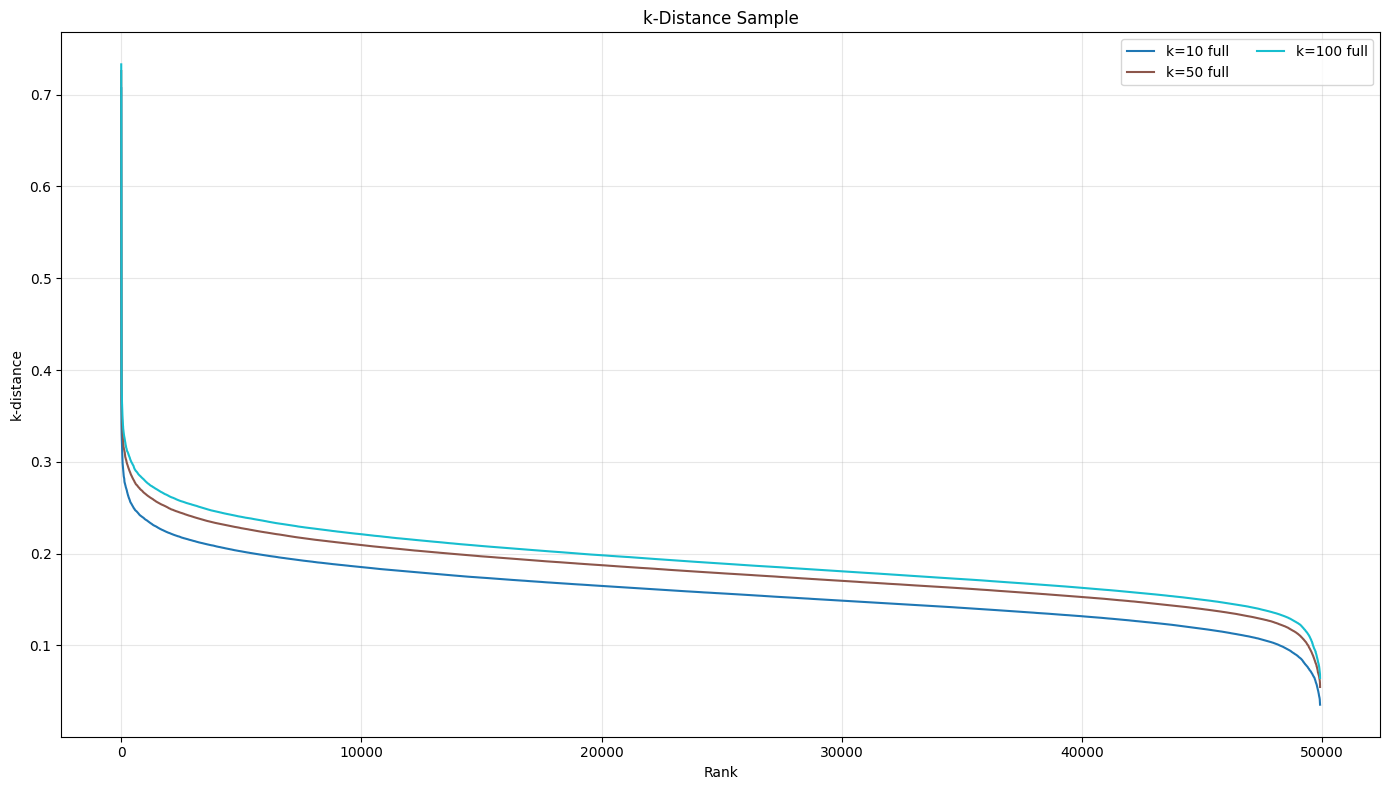

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb

k_values = [10, 50, 100]

fig, ax = plt.subplots(figsize=(14, 8))

colors = plt.cm.tab10(np.linspace(0, 1, len(k_values)))

for k, color in zip(k_values, colors):

    # sample 
    sample_distances = k_dists_sample[f"k_distance_{k}"].values
    sample_distances_sorted = np.sort(sample_distances)[::-1]
    sample_rank = np.arange(len(sample_distances_sorted))

    # Create lighter version of the color
    rgb = np.array(to_rgb(color))
    light_color = rgb + (1 - rgb) * 0.6

    # Sample dataset
    ax.plot(
        sample_rank,
        sample_distances_sorted,
        color=color,
        label=f"k={k} full"
    )


ax.set_xlabel("Rank")
ax.set_ylabel("k-distance")
ax.set_title("k-Distance Sample")
ax.legend(ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# plot kDist full and sample together

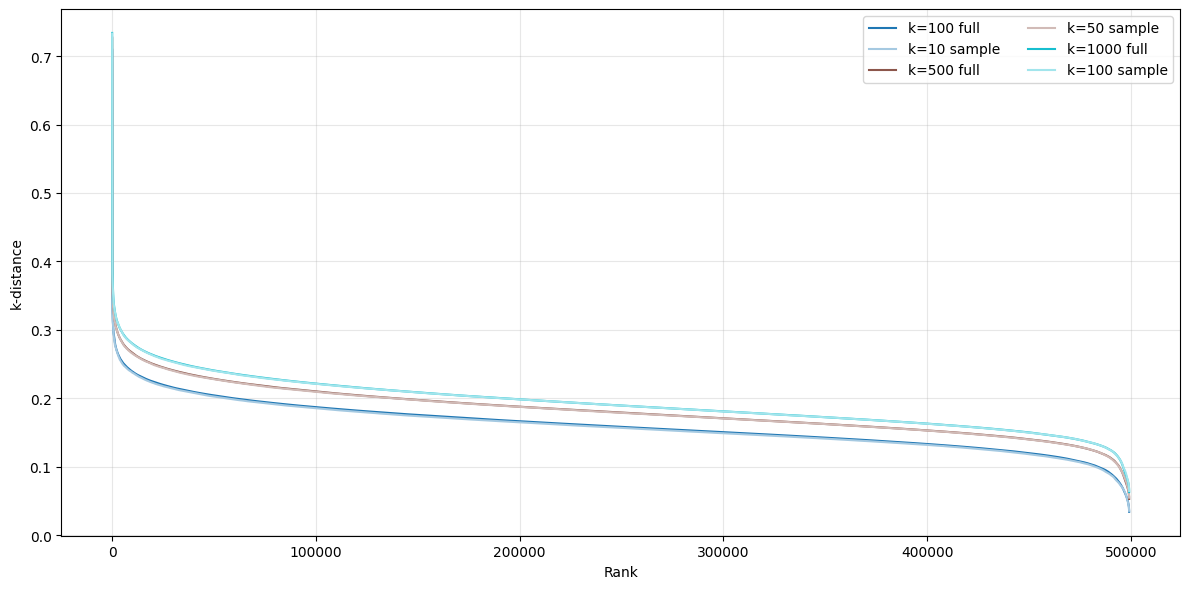

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb

k_values_full = [100, 500, 1000]
k_values_sample = [10, 50, 100]

fig, ax = plt.subplots(figsize=(12, 6))

# One base color for each full/sample pair
colors = plt.cm.tab10(np.linspace(0, 1, len(k_values_full)))

for k_full, k_sample, color in zip(
    k_values_full,
    k_values_sample,
    colors
):

    # -------------------------
    # Full dataset
    # -------------------------
    full_distances = k_dists_full[
        f"k_distance_{k_full}"
    ].values

    full_distances_sorted = np.sort(full_distances)[::-1]
    full_rank = np.arange(len(full_distances_sorted))

    # -------------------------
    # Sample
    # -------------------------
    sample_distances = k_dists_sample[
        f"k_distance_{k_sample}"
    ].values

    sample_distances_sorted = np.sort(sample_distances)[::-1]
    sample_rank = np.arange(len(sample_distances_sorted))

    # Scale sample rank to full dataset scale
    sample_rank_scaled = sample_rank * 10

    # -------------------------
    # Create lighter version
    # -------------------------
    rgb = np.array(to_rgb(color))
    light_color = rgb + (1 - rgb) * 0.6

    # -------------------------
    # Plot full = dark
    # -------------------------
    ax.plot(
        full_rank,
        full_distances_sorted,
        color=color,
        label=f"k={k_full} full"
    )

    # -------------------------
    # Plot sample = light
    # -------------------------
    ax.plot(
        sample_rank_scaled,
        sample_distances_sorted,
        color=light_color,
        label=f"k={k_sample} sample"
    )

ax.set_xlabel("Rank")
ax.set_ylabel("k-distance")
#ax.set_title("k-Distance Comparison: Full Dataset vs. Sample")

ax.legend(ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

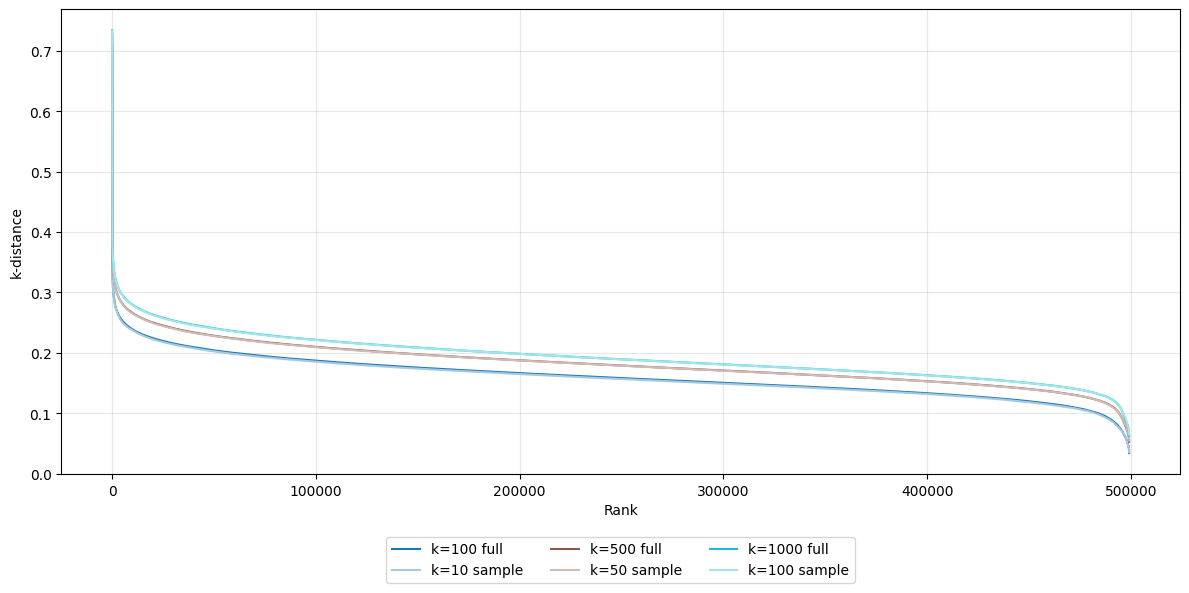

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb

k_values_full = [100, 500, 1000]
k_values_sample = [10, 50, 100]

fig, ax = plt.subplots(figsize=(12, 6))

# One base color for each full/sample pair
colors = plt.cm.tab10(np.linspace(0, 1, len(k_values_full)))

for k_full, k_sample, color in zip(
    k_values_full,
    k_values_sample,
    colors
):

    # -------------------------
    # Full dataset
    # -------------------------
    full_distances = k_dists_full[
        f"k_distance_{k_full}"
    ].values

    full_distances_sorted = np.sort(full_distances)[::-1]
    full_rank = np.arange(len(full_distances_sorted))

    # -------------------------
    # Sample
    # -------------------------
    sample_distances = k_dists_sample[
        f"k_distance_{k_sample}"
    ].values

    sample_distances_sorted = np.sort(sample_distances)[::-1]
    sample_rank = np.arange(len(sample_distances_sorted))

    # Scale sample rank to full dataset scale
    sample_rank_scaled = sample_rank * 10

    # -------------------------
    # Create lighter version
    # -------------------------
    rgb = np.array(to_rgb(color))
    light_color = rgb + (1 - rgb) * 0.6

    # -------------------------
    # Plot full = dark
    # -------------------------
    ax.plot(
        full_rank,
        full_distances_sorted,
        color=color,
        label=f"k={k_full} full"
    )

    # -------------------------
    # Plot sample = light
    # -------------------------
    ax.plot(
        sample_rank_scaled,
        sample_distances_sorted,
        color=light_color,
        label=f"k={k_sample} sample"
    )

ax.set_xlabel("Rank")
ax.set_ylabel("k-distance")

# Legend at the bottom
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=3,
    frameon=True
)

ax.grid(True, alpha=0.3)

# Leave room for the legend
plt.tight_layout()
plt.subplots_adjust(bottom=0.20)

plt.show()

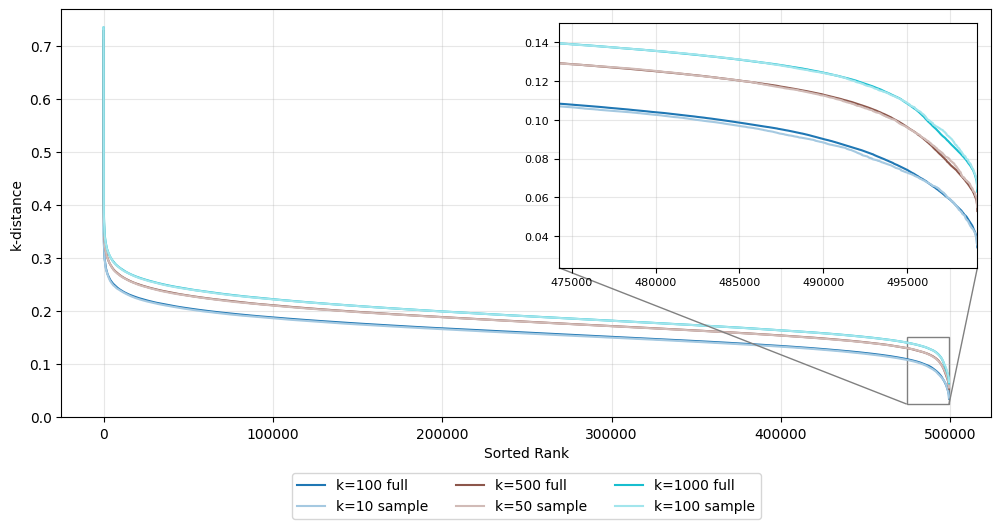

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

k_values_full = [100, 500, 1000]
k_values_sample = [10, 50, 100]

fig, ax = plt.subplots(figsize=(12, 6))

# One base color for each full/sample pair
colors = plt.cm.tab10(np.linspace(0, 1, len(k_values_full)))

for k_full, k_sample, color in zip(
    k_values_full,
    k_values_sample,
    colors
):

    # -------------------------
    # Full dataset
    # -------------------------
    full_distances = k_dists_full[
        f"k_distance_{k_full}"
    ].values

    full_distances_sorted = np.sort(full_distances)[::-1]
    full_rank = np.arange(len(full_distances_sorted))

    # -------------------------
    # Sample
    # -------------------------
    sample_distances = k_dists_sample[
        f"k_distance_{k_sample}"
    ].values

    sample_distances_sorted = np.sort(sample_distances)[::-1]
    sample_rank = np.arange(len(sample_distances_sorted))

    # Scale sample rank to full dataset scale
    sample_rank_scaled = sample_rank * 10

    # -------------------------
    # Create lighter version
    # -------------------------
    rgb = np.array(to_rgb(color))
    light_color = rgb + (1 - rgb) * 0.6

    # -------------------------
    # Plot full = dark
    # -------------------------
    ax.plot(
        full_rank,
        full_distances_sorted,
        color=color,
        label=f"k={k_full} full"
    )

    # -------------------------
    # Plot sample = light
    # -------------------------
    ax.plot(
        sample_rank_scaled,
        sample_distances_sorted,
        color=light_color,
        label=f"k={k_sample} sample"
    )


# =========================================================
# MAIN AXIS
# =========================================================

ax.set_xlabel("Sorted Rank")
ax.set_ylabel("k-distance")

ax.grid(True, alpha=0.3)


# =========================================================
# ZOOMED INSET
# =========================================================

# Create inset in the upper-right corner
axins = inset_axes(
    ax,
    width="45%",      # width relative to main axes
    height="60%",     # height relative to main axes
    loc="upper right",
    borderpad=1
)

# Plot the same curves again in the inset
for k_full, k_sample, color in zip(
    k_values_full,
    k_values_sample,
    colors
):

    # Full
    full_distances = k_dists_full[
        f"k_distance_{k_full}"
    ].values

    full_distances_sorted = np.sort(full_distances)[::-1]
    full_rank = np.arange(len(full_distances_sorted))

    # Sample
    sample_distances = k_dists_sample[
        f"k_distance_{k_sample}"
    ].values

    sample_distances_sorted = np.sort(sample_distances)[::-1]
    sample_rank = np.arange(len(sample_distances_sorted))
    sample_rank_scaled = sample_rank * 10

    # Light color
    rgb = np.array(to_rgb(color))
    light_color = rgb + (1 - rgb) * 0.6

    # Full
    axins.plot(
        full_rank,
        full_distances_sorted,
        color=color
    )

    # Sample
    axins.plot(
        sample_rank_scaled,
        sample_distances_sorted,
        color=light_color
    )


# =========================================================
# SET THE ZOOM REGION
# =========================================================

# Example: zoom into the last 20% of the graph
max_rank = max(
    len(k_dists_full[f"k_distance_{k}"].values)
    for k in k_values_full
)

zoom_start = int(max_rank * 0.95)
zoom_end = max_rank

axins.set_xlim(zoom_start, zoom_end)

# Automatically determine a sensible y-range for the zoom
zoom_values = []

for k_full, k_sample in zip(k_values_full, k_values_sample):

    full_distances = np.sort(
        k_dists_full[f"k_distance_{k_full}"].values
    )[::-1]

    sample_distances = np.sort(
        k_dists_sample[f"k_distance_{k_sample}"].values
    )[::-1]

    # Full values in zoom range
    zoom_values.extend(
        full_distances[
            zoom_start:min(zoom_end, len(full_distances))
        ]
    )

    # Sample values in zoom range
    sample_start = zoom_start // 10
    sample_end = zoom_end // 10

    zoom_values.extend(
        sample_distances[
            sample_start:min(sample_end, len(sample_distances))
        ]
    )

# Add a little padding around the y range
y_min = min(zoom_values)
y_max = max(zoom_values)
padding = (y_max - y_min) * 0.1

axins.set_ylim(
    y_min - padding,
    y_max + padding
)

mark_inset(
    ax,
    axins,
    loc1=3,
    loc2=4,
    fc="none",
    ec="0.5"
)

axins.grid(True, alpha=0.3)

# Smaller tick labels
axins.tick_params(axis="both", labelsize=8)


# =========================================================
# LEGEND
# =========================================================

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=3,
    frameon=True
)

# Leave room for legend
#plt.tight_layout()
plt.subplots_adjust(bottom=0.20)

plt.show()

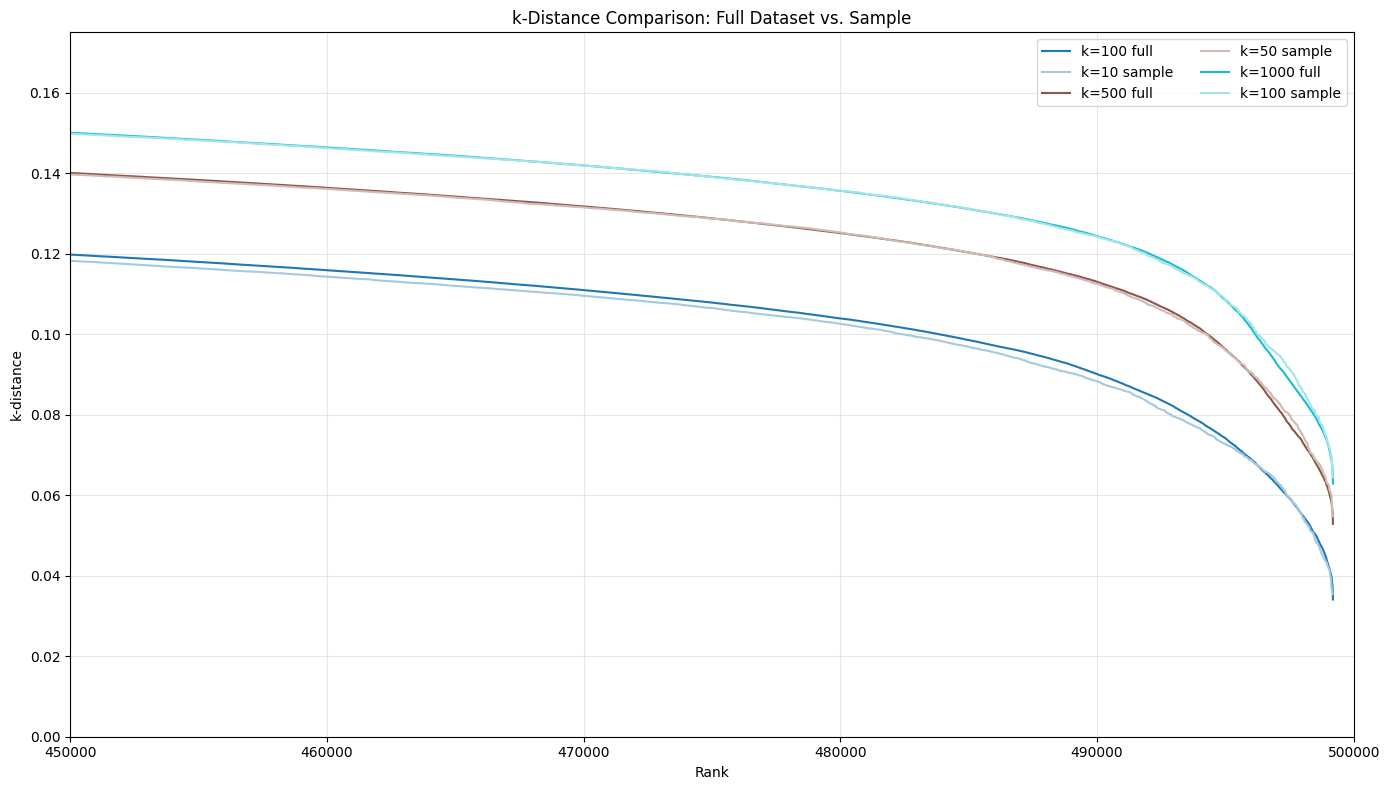

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb

k_values_full = [100, 500, 1000]
k_values_sample = [10, 50, 100]

fig, ax = plt.subplots(figsize=(14, 8))

# One base color for each full/sample pair
colors = plt.cm.tab10(np.linspace(0, 1, len(k_values_full)))

for k_full, k_sample, color in zip(
    k_values_full,
    k_values_sample,
    colors
):

    # -------------------------
    # Full dataset
    # -------------------------
    full_distances = k_dists_full[
        f"k_distance_{k_full}"
    ].values

    full_distances_sorted = np.sort(full_distances)[::-1]
    full_rank = np.arange(len(full_distances_sorted))

    # -------------------------
    # Sample
    # -------------------------
    sample_distances = k_dists_sample[
        f"k_distance_{k_sample}"
    ].values

    sample_distances_sorted = np.sort(sample_distances)[::-1]
    sample_rank = np.arange(len(sample_distances_sorted))

    # Scale sample rank to full dataset scale
    sample_rank_scaled = sample_rank * 10

    # -------------------------
    # Create lighter version
    # -------------------------
    rgb = np.array(to_rgb(color))
    light_color = rgb + (1 - rgb) * 0.6

    # -------------------------
    # Plot full = dark
    # -------------------------
    ax.plot(
        full_rank,
        full_distances_sorted,
        color=color,
        label=f"k={k_full} full"
    )

    # -------------------------
    # Plot sample = light
    # -------------------------
    ax.plot(
        sample_rank_scaled,
        sample_distances_sorted,
        color=light_color,
        label=f"k={k_sample} sample"
    )

ax.set_xlabel("Rank")
ax.set_ylabel("k-distance")
ax.set_title("k-Distance Comparison: Full Dataset vs. Sample")

# Zoom into region of interest
ax.set_xlim(450_000, 500_000)
ax.set_ylim(0, 0.175)

ax.legend(ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# plot difference of full vs sample

In [12]:
import numpy as np
import pandas as pd

k_values_full = [100, 500, 1000]
k_values_sample = [10, 50, 100]

differences = {}

for k_full, k_sample in zip(k_values_full, k_values_sample):

    # Full distances, sorted
    full_distances = np.sort(
        k_dists_full[f"k_distance_{k_full}"].values
    )[::-1]

    # Sample distances, sorted
    sample_distances = np.sort(
        k_dists_sample[f"k_distance_{k_sample}"].values
    )[::-1]

    # Ranks in the sample
    sample_rank = np.arange(len(sample_distances))

    # Corresponding ranks in the full dataset
    full_rank = sample_rank * 10

    # Only keep ranks that actually exist in the full dataset
    valid = full_rank < len(full_distances)

    sample_rank = sample_rank[valid]
    full_rank = full_rank[valid]

    # Calculate difference
    diff = (
        full_distances[full_rank]
        - sample_distances[sample_rank]
    )

    differences[k_full] = diff


difference_df = pd.DataFrame({
    f"full_{k_full}_sample_{k_sample}":
        differences[k_full]
    for k_full, k_sample in zip(
        k_values_full,
        k_values_sample
    )
})

difference_df.head()

,full_100_sample_10,full_500_sample_50,full_1000_sample_100
0,0.002369,0.001452,0.000972
1,-0.031470,-0.031671,-0.030639
2,-0.146268,-0.132797,-0.126173
3,-0.025448,-0.028377,-0.023001
4,0.013861,0.002121,0.014817


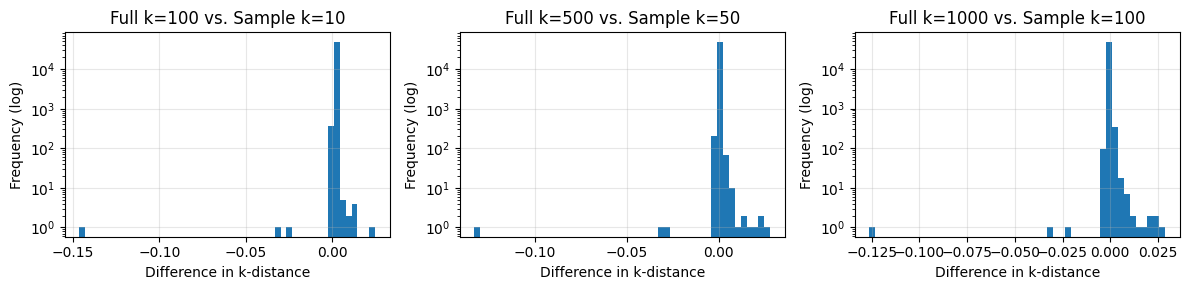

In [30]:
fig, axes = plt.subplots(
    1, 3,
    figsize=(12, 3)
)

axes = axes.flatten()

for ax, (k_full, k_sample) in zip(
    axes,
    zip(k_values_full, k_values_sample)
):

    diff = differences[k_full]

    ax.hist(
        diff,
        bins=50
    )

    ax.set_title(
        f"Full k={k_full} vs. Sample k={k_sample}"
    )

    ax.set_xlabel("Difference in k-distance")
    ax.set_ylabel("Frequency (log)")

    ax.set_yscale("log")  # logarithmic y-axis

    ax.grid(
        True,
        alpha=0.3
    )

plt.tight_layout()
plt.show()

Note on graph: full - sample

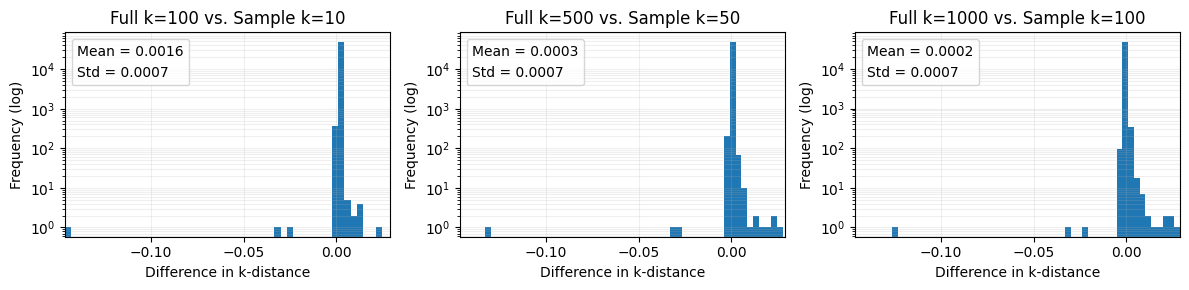

In [40]:
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator


fig, axes = plt.subplots(
    1, 3,
    figsize=(12, 3)
)

axes = axes.flatten()

for ax, (k_full, k_sample) in zip(
    axes,
    zip(k_values_full, k_values_sample)
):

    diff = differences[k_full]

    mean = np.mean(diff)
    std = np.std(diff)

    ax.hist(
        diff,
        bins=50
    )

    # Text-only legend entries
    mean_handle = Line2D(
        [], [],
        linestyle="none",
        marker="",
        label=f"Mean = {mean:.4f}"
    )

    std_handle = Line2D(
        [], [],
        linestyle="none",
        marker="",
        label=f"Std = {std:.4f}"
    )

    ax.legend(
        handles=[mean_handle, std_handle],
        handlelength=0,
        handletextpad=0
    )

    ax.set_title(
        f"Full k={k_full} vs. Sample k={k_sample}"
    )

    ax.set_xlabel("Difference in k-distance")
    ax.set_ylabel("Frequency (log)")

    ax.set_yscale("log")

    ax.grid(
        True,
        which="both",
        alpha=0.2
    )

    all_diffs = np.concatenate([
    differences[k] for k in k_values_full
    ])

    x_min = all_diffs.min()
    x_max = all_diffs.max()

    for ax in axes:
        ax.set_xlim(x_min, x_max)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=4))

plt.tight_layout()
plt.show()

    

In [30]:
from scipy.stats import jarque_bera

for k_full, diff in differences.items():
    statistic, p_value = jarque_bera(diff)

    print(f"k={k_full}")
    print(f"  JB statistic: {statistic:.4f}")
    print(f"  p-value:      {p_value:.4g}")
    print()

k=100
  JB statistic: 2112298347771.3196
  p-value:      0

k=500
  JB statistic: 1135263931962.9905
  p-value:      0

k=1000
  JB statistic: 808618529718.1267
  p-value:      0



In [32]:
from scipy.stats import jarque_bera
import pandas as pd
import numpy as np

results = []

for k_full, k_sample in zip(k_values_full, k_values_sample):

    diff = differences[k_full]

    # Jarque-Bera test
    jb_stat, p_value = jarque_bera(diff)

    # Descriptive statistics
    mean = np.mean(diff)
    std = np.std(diff, ddof=1)  # sample standard deviation # TODO: check

    results.append({
        "k_full": k_full,
        "k_sample": k_sample,
        "mean": mean,
        "std": std,
        "JB_statistic": jb_stat,
        "p_value": p_value,
        "normal_at_0.05": p_value >= 0.05
    })

jb_results = pd.DataFrame(results)

jb_results

,k_full,k_sample,mean,std,JB_statistic,p_value,normal_at_0.05
0,100,10,0.001556,0.000741,2.112298e+12,0.0,False
1,500,50,0.000337,0.000722,1.135264e+12,0.0,False
2,1000,100,0.000210,0.000716,8.086185e+11,0.0,False
